In [1]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import optuna
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 멀티-GPU 사용 시
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
CFG = {
    'SR':16000,
    'N_MFCC':20, # MFCC 벡터를 추출할 개수
}

# Data load
- row: 1802

In [2]:
import zipfile

# 파일 경로
zip_file_path_list = [
                 './DEAM/DEAM_Annotations.zip',
                 './DEAM/DEAM_audio.zip'
                 ]

# 압축 해제
for zip_file_path in zip_file_path_list:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
      zip_ref.extractall('./DEAM')

print(f"{zip_file_path} 압축 해제 완료!")

./DEAM/DEAM_audio.zip 압축 해제 완료!


In [4]:
# 오디오 파일 디렉토리 경로
audio_dir = './DEAM/MEMD_audio/'

# 주석 파일 로드 및 병합
annotations1 = pd.read_csv('./DEAM/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv')
annotations2 = pd.read_csv('./DEAM/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv')
annotations = pd.concat([annotations1, annotations2], ignore_index=True)

annotations.columns = ['song_id', 'valence_mean', 'valence_std', 'arousal_mean',
       'arousal_std', 'valence_ max_mean', 'valence_max_std',
       'valence_min_mean', 'valence_min_std', 'arousal_max_mean',
       'arousal_max_std', 'arousal_min_mean', 'arousal_min_std']

In [3]:
annotations

,song_id,valence_mean,valence_std,arousal_mean,arousal_std,valence_ max_mean,valence_max_std,valence_min_mean,valence_min_std,arousal_max_mean,arousal_max_std,arousal_min_mean,arousal_min_std
0,2,3.10,0.94,3.00,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,3.50,1.75,3.30,1.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,5.70,1.42,5.50,1.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,4.40,2.01,5.30,1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,5.80,1.47,6.40,1.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797,2054,5.40,1.20,3.60,1.36,6.0,1.10,4.40,1.36,4.20,1.33,2.40,0.80
1798,2055,5.00,1.41,5.20,1.47,6.0,1.41,4.20,1.33,6.40,1.62,4.00,1.41
1799,2056,5.00,1.41,4.60,1.74,5.6,1.62,4.40,1.36,5.00,1.79,4.00,1.67
1800,2057,3.17,1.07,6.83,0.37,4.5,0.76,2.17,0.90,8.17,0.90,4.83,1.46


# MFCC

In [5]:
song_id = annotations.iloc[0].song_id
file_path = os.path.join(audio_dir, f'{int(song_id)}.mp3')

audio, sr = librosa.load(file_path, sr=16000)
print('sr:', sr, ', audio shape:', audio.shape)
print('length:', audio.shape[0]/float(sr), 'secs')

sr: 16000 , audio shape: (720976,)
length: 45.061 secs


- 초당 sample: 16000개

# MFCC

## DNN

In [11]:
class MultivariateRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim=2):
        super(MultivariateRegressionModel, self).__init__()

        self.model = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(32),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# loss function
def loss_fn(y_pred, y_true):
    # 각 출력에 대한 MSE 계산
    mse = nn.MSELoss(reduction='none')
    loss = mse(y_pred, y_true)
    # 각 출력의 손실 반환
    return loss.mean(dim=0)

### Train

In [12]:
input_dim = X_train_tensor.shape[1]
model = MultivariateRegressionModel(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 파라미터 설정
epochs = 30
train_loss_v = []
train_loss_a = []
val_loss_v = []
val_loss_a = []

# 훈련 루프
model.train()
for epoch in range(epochs):
    total_train_loss = torch.zeros(2)
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.sum().backward()
        optimizer.step()
        total_train_loss += loss.detach()
    avg_train_loss = total_train_loss / len(train_loader)

    # 검증 루프
    model.eval()
    with torch.no_grad():
        total_val_loss = torch.zeros(2)
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_val_loss += loss
        avg_val_loss = total_val_loss / len(val_loader)

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {avg_train_loss[0].item():.4f}, {avg_train_loss[1].item():.4f}, '
          f'Val Loss: {avg_val_loss[0].item():.4f}, {avg_val_loss[1].item():.4f}')

    train_loss_v.append(avg_train_loss[0].item())
    train_loss_a.append(avg_train_loss[1].item())
    val_loss_v.append(avg_val_loss[0].item())
    val_loss_a.append(avg_val_loss[1].item())

Epoch [1/30], Train Loss: 26.5981, 24.1238, Val Loss: 25.7790, 22.2015
Epoch [2/30], Train Loss: 19.8557, 17.3984, Val Loss: 9.2245, 7.5082
Epoch [3/30], Train Loss: 5.0211, 4.3653, Val Loss: 1.9820, 1.5966
Epoch [4/30], Train Loss: 1.2265, 1.3835, Val Loss: 1.1885, 1.1081
Epoch [5/30], Train Loss: 0.9075, 1.0534, Val Loss: 1.0269, 0.9642
Epoch [6/30], Train Loss: 0.8247, 0.9921, Val Loss: 0.9994, 0.9523
Epoch [7/30], Train Loss: 0.7805, 0.9438, Val Loss: 0.9605, 0.8987
Epoch [8/30], Train Loss: 0.7566, 0.9065, Val Loss: 0.9422, 0.9134
Epoch [9/30], Train Loss: 0.7399, 0.8651, Val Loss: 0.9488, 0.8963
Epoch [10/30], Train Loss: 0.7238, 0.8460, Val Loss: 0.9341, 0.8880
Epoch [11/30], Train Loss: 0.7101, 0.8201, Val Loss: 0.9411, 0.9080
Epoch [12/30], Train Loss: 0.6926, 0.8012, Val Loss: 0.9419, 0.9216
Epoch [13/30], Train Loss: 0.6878, 0.7708, Val Loss: 0.9961, 0.9549
Epoch [14/30], Train Loss: 0.6674, 0.7538, Val Loss: 0.9565, 0.9251
Epoch [15/30], Train Loss: 0.6613, 0.7337, Val Loss

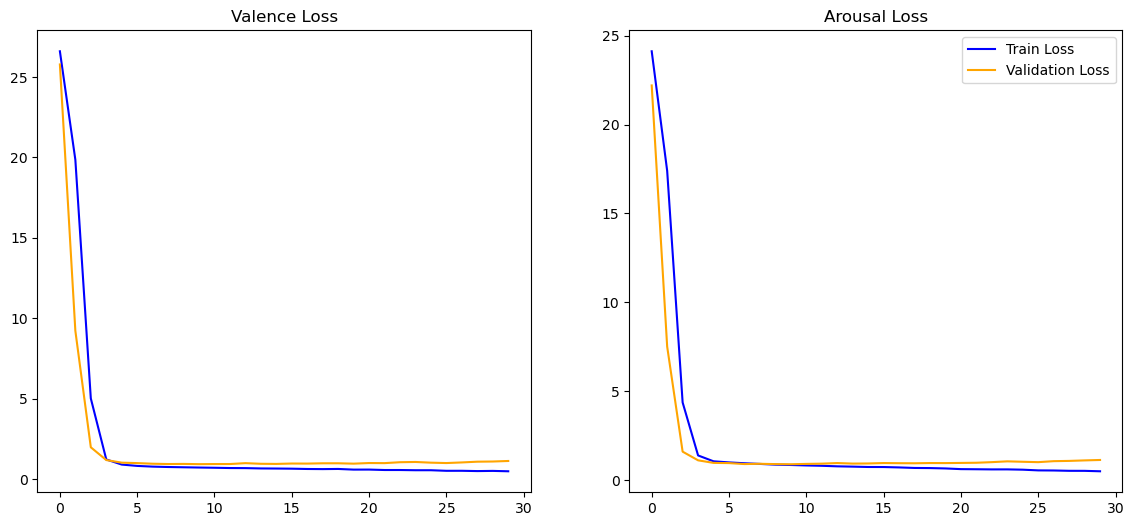

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].set_title('Valence Loss')
axs[0].plot(train_loss_v, label='Train Loss', color='blue')
axs[0].plot(val_loss_v, label='Validation Loss', color='orange')

axs[1].set_title('Arousal Loss')
axs[1].plot(train_loss_a, label='Train Loss', color='blue')
axs[1].plot(val_loss_a, label='Validation Loss', color='orange')
plt.legend()

### Test

In [14]:
# 테스트 데이터 예측
model.eval()
with torch.no_grad():
    dnn_pred_tensor = model(X_val_tensor)
    dnn_pred = dnn_pred_tensor.numpy()

# 평가 지표 계산
from sklearn.metrics import mean_squared_error, r2_score
y_test = y_val_tensor.numpy()
mse = mean_squared_error(y_test, dnn_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_test, dnn_pred, multioutput='raw_values')

print(f'MSE for each output: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2 Score: {r2}')

MSE for each output: [1.1210518 1.1429396]
RMSE: [1.0587974 1.0690836]
R^2 Score: [0.16363025 0.22703952]


### Optuna

In [50]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score

def objective(trial):
    # 하이퍼파라미터 샘플링
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    hidden_units_1 = trial.suggest_int("hidden_units_1", 32, 256, step=32)
    hidden_units_2 = trial.suggest_int("hidden_units_2", 32, 256, step=32)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    
    # 모델 정의
    class OptimizedDNN(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.model = nn.Sequential(
                nn.BatchNorm1d(input_dim),
                nn.Linear(input_dim, hidden_units_1),
                nn.ReLU(),
                nn.Dropout(dropout_rate),

                nn.BatchNorm1d(hidden_units_1),
                nn.Linear(hidden_units_1, hidden_units_2),
                nn.ReLU(),
                nn.Dropout(dropout_rate),

                nn.BatchNorm1d(hidden_units_2),
                nn.Linear(hidden_units_2, 2)
            )
            
        def forward(self, x):
            return self.model(x)

    # 모델 인스턴스 생성
    input_dim = X_train_tensor.shape[1]
    model = OptimizedDNN(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 학습 루프
    model.train()
    for epoch in range(30):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.sum().backward()
            optimizer.step()
    
    # 검증 성능 평가
    model.eval()
    with torch.no_grad():
        total_val_loss = torch.zeros(2)
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_val_loss += loss
        avg_val_loss = total_val_loss / len(val_loader)
        
    # R^2 값을 최대화하기 위해 -R2 사용
    return -r2_score(y_val_tensor.numpy(), model(X_val_tensor).detach().numpy(), multioutput='uniform_average')

# Optuna 스터디 실행
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# 최적의 하이퍼파라미터 확인
best_dnn_trial = study.best_trial
print(f"Best R2: {-best_dnn_trial.value}")
print("Best Hyperparameters:")
for key, value in best_dnn_trial.params.items():
    print(f"{key}: {value}")

[I 2025-01-16 15:50:26,224] A new study created in memory with name: no-name-02db683d-7ebd-413e-b6de-85864088bf68
[I 2025-01-16 15:50:28,088] Trial 0 finished with value: -0.29374682903289795 and parameters: {'lr': 0.009815632068819446, 'hidden_units_1': 256, 'hidden_units_2': 224, 'dropout_rate': 0.2466765949555094}. Best is trial 0 with value: -0.29374682903289795.
[I 2025-01-16 15:50:29,877] Trial 1 finished with value: -0.30728110671043396 and parameters: {'lr': 0.004103114827527414, 'hidden_units_1': 256, 'hidden_units_2': 32, 'dropout_rate': 0.11350816135730711}. Best is trial 1 with value: -0.30728110671043396.
[W 2025-01-16 15:50:31,296] Trial 2 failed with parameters: {'lr': 1.536140871955342e-05, 'hidden_units_1': 32, 'hidden_units_2': 64, 'dropout_rate': 0.34868906338638417} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\ProgramData\Anaconda3\lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or

KeyboardInterrupt: 

- Best R2: 0.37485772371292114
- Best Hyperparameters:
- lr: 0.0036993389420427007
- hidden_units_1: 192
- hidden_units_2: 96
- dropout_rate: 0.4783484389328778

- Best R2: 0.3666655421257019
- Best Hyperparameters:
- lr: 0.002816268546843397
- hidden_units_1: 128
- hidden_units_2: 160
- dropout_rate: 0.47803232734004897

In [47]:
# Optuna 최적의 하이퍼파라미터 불러오기
best_dnn_params = study.best_trial.params
lr = best_dnn_params["lr"]
hidden_units_1 = best_dnn_params["hidden_units_1"]
hidden_units_2 = best_dnn_params["hidden_units_2"]
dropout_rate = best_dnn_params["dropout_rate"]

class OptimizedDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, hidden_units_1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.BatchNorm1d(hidden_units_1),
            nn.Linear(hidden_units_1, hidden_units_2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.BatchNorm1d(hidden_units_2),
            nn.Linear(hidden_units_2, 2)  # Valence & Arousal 예측
        )
        
    def forward(self, x):
        return self.model(x)

# 데이터 크기 가져오기
input_dim = X_train_tensor.shape[1]

# 모델 인스턴스 생성 (최적 파라미터 적용)
model = OptimizedDNN(input_dim)

# Adam 옵티마이저 & 학습률 적용
optimizer = optim.Adam(model.parameters(), lr=lr)

# 학습 파라미터 설정
epochs = 30
train_loss_v = []
train_loss_a = []
val_loss_v = []
val_loss_a = []

# 학습 루프
for epoch in range(epochs):
    model.train()
    total_train_loss = torch.zeros(2)
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.sum().backward()
        optimizer.step()
        total_train_loss += loss.detach()
    avg_train_loss = total_train_loss / len(train_loader)

    # 검증 루프
    model.eval()
    with torch.no_grad():
        total_val_loss = torch.zeros(2)
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_val_loss += loss
        avg_val_loss = total_val_loss / len(val_loader)

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {avg_train_loss[0]:.4f}, {avg_train_loss[1]:.4f}, '
          f'Val Loss: {avg_val_loss[0]:.4f}, {avg_val_loss[1]:.4f}')

    train_loss_v.append(avg_train_loss[0].item())
    train_loss_a.append(avg_train_loss[1].item())
    val_loss_v.append(avg_val_loss[0].item())
    val_loss_a.append(avg_val_loss[1].item())

Epoch [1/30], Train Loss: 22.8022, 21.0122, Val Loss: 15.5185, 14.2524
Epoch [2/30], Train Loss: 8.4104, 7.7732, Val Loss: 1.3349, 1.3937
Epoch [3/30], Train Loss: 2.7417, 2.8078, Val Loss: 1.0501, 1.0615
Epoch [4/30], Train Loss: 1.8499, 1.9041, Val Loss: 0.9585, 1.0244
Epoch [5/30], Train Loss: 1.5416, 1.6769, Val Loss: 0.9226, 0.9481
Epoch [6/30], Train Loss: 1.4285, 1.5836, Val Loss: 0.9205, 0.9483
Epoch [7/30], Train Loss: 1.2850, 1.4359, Val Loss: 0.9505, 0.9430
Epoch [8/30], Train Loss: 1.1630, 1.3429, Val Loss: 0.9157, 0.9431
Epoch [9/30], Train Loss: 1.0504, 1.2203, Val Loss: 0.9297, 0.9487
Epoch [10/30], Train Loss: 0.9646, 1.0672, Val Loss: 0.8976, 0.9478
Epoch [11/30], Train Loss: 1.0243, 1.1841, Val Loss: 0.8985, 0.9189
Epoch [12/30], Train Loss: 1.0088, 1.1340, Val Loss: 0.9066, 0.9534
Epoch [13/30], Train Loss: 0.9289, 1.0758, Val Loss: 0.9078, 0.9210
Epoch [14/30], Train Loss: 0.9249, 1.0688, Val Loss: 0.9231, 0.9231
Epoch [15/30], Train Loss: 0.8842, 1.0522, Val Loss: 

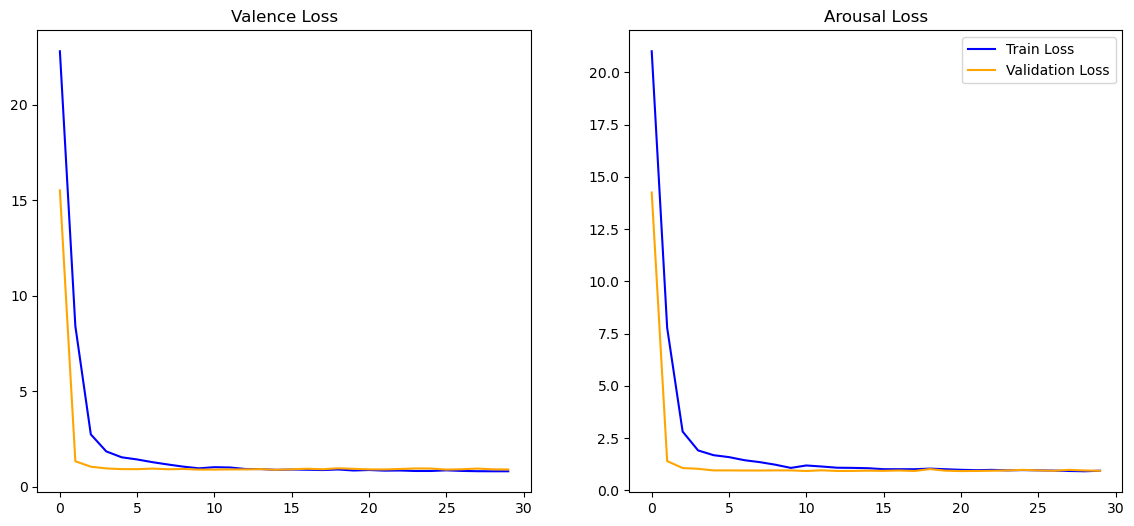

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].set_title('Valence Loss')
axs[0].plot(train_loss_v, label='Train Loss', color='blue')
axs[0].plot(val_loss_v, label='Validation Loss', color='orange')

axs[1].set_title('Arousal Loss')
axs[1].plot(train_loss_a, label='Train Loss', color='blue')
axs[1].plot(val_loss_a, label='Validation Loss', color='orange')
plt.legend()

In [49]:
# 테스트 데이터 예측
model.eval()
with torch.no_grad():
    best_dnn_pred_tensor = model(X_val_tensor)
    best_dnn_pred = best_dnn_pred_tensor.numpy()

# 성능 평가
from sklearn.metrics import mean_squared_error, r2_score
y_test = y_val_tensor.numpy()
mse = mean_squared_error(y_test, best_dnn_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_test, best_dnn_pred, multioutput='raw_values')

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2 Score: {r2}')

MSE: [0.89008343 0.9341879 ]
RMSE: [0.94344234 0.96653396]
R^2 Score: [0.33594608 0.3682165 ]


## XGBoost

In [22]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

xgb = MultiOutputRegressor(XGBRegressor())

xgb.fit(X_train_scaled, y_train)

xgb_pred = xgb.predict(X_val_scaled)

mse = mean_squared_error(y_val, xgb_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, xgb_pred)
print(f'RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'R2: {r2}')

RMSE (Valence): 1.0149, RMSE (Arousal): 0.9856
R2: 0.28725972570897307


In [23]:
import optuna
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Optuna의 목적 함수 정의
def objective(trial):
    # 하이퍼파라미터를 탐색 범위에서 선택
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)

    # XGBRegressor 인스턴스 생성
    xgb = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42
        )
    )
    
    # 모델 학습
    xgb.fit(X_train_scaled, y_train)

    # 예측 및 평가
    xgb_pred = xgb.predict(X_val_scaled)
    mse = mean_squared_error(y_val, xgb_pred, multioutput='raw_values')
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, xgb_pred)
    
    # R2 값을 최대화하기 위해 -r2 사용
    return -r2

# Optuna 스터디 생성 및 최적화 수행
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# 최적의 하이퍼파라미터 출력
print("Best trial:")
best_trial = study.best_trial
print(f"  Value: {-best_trial.value}")  # R2는 -를 취소
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-01-16 15:22:05,494] A new study created in memory with name: no-name-cc954e64-f45e-45f4-8ccd-1d6eb03f3f35
[I 2025-01-16 15:22:09,855] Trial 0 finished with value: -0.33333163130026994 and parameters: {'n_estimators': 228, 'max_depth': 18, 'learning_rate': 0.06366438105482997, 'subsample': 0.9393479422165676, 'colsample_bytree': 0.9890608894389448}. Best is trial 0 with value: -0.33333163130026994.
[I 2025-01-16 15:22:09,935] Trial 1 finished with value: -0.35410514251724073 and parameters: {'n_estimators': 113, 'max_depth': 3, 'learning_rate': 0.1508985028142052, 'subsample': 0.8813499054369662, 'colsample_bytree': 0.6828610929840326}. Best is trial 1 with value: -0.35410514251724073.
[I 2025-01-16 15:22:10,306] Trial 2 finished with value: -0.30759083551038763 and parameters: {'n_estimators': 156, 'max_depth': 7, 'learning_rate': 0.10001984486252971, 'subsample': 0.5658449124346423, 'colsample_bytree': 0.5490856529037632}. Best is trial 1 with value: -0.35410514251724073.
[I 2

Best trial:
  Value: 0.38480443877112996
  Params:
    n_estimators: 254
    max_depth: 4
    learning_rate: 0.02474392328312022
    subsample: 0.5452460918356992
    colsample_bytree: 0.8738465753628732
Optimal RMSE (Valence): 0.9443, RMSE (Arousal): 0.9141
Optimal R2: 0.3848


In [24]:
# 최적의 하이퍼파라미터로 모델 재학습 및 평가
best_params = study.best_params
best_model = MultiOutputRegressor(
    XGBRegressor(**best_params, random_state=42)
)
best_model.fit(X_train_scaled, y_train)
best_xgb_pred = best_model.predict(X_val_scaled)

# 최적 모델의 성능 확인
mse = mean_squared_error(y_val, best_xgb_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, best_xgb_pred)

print(f'Optimal RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'Optimal R2: {r2:.4f}')

Optimal RMSE (Valence): 0.9443, RMSE (Arousal): 0.9141
Optimal R2: 0.3848


## LightGBM

In [25]:
from lightgbm import LGBMRegressor

lgb = MultiOutputRegressor(LGBMRegressor())
lgb.fit(X_train_scaled, y_train)
lgb_pred = lgb.predict(X_val_scaled)

mse = mean_squared_error(y_val, lgb_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, lgb_pred)
print(f'RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'R2: {r2}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000608 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1441, number of used features: 20
[LightGBM] [Info] Start training from score 4.924476
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1441, number of used features: 20
[LightGBM] [Info] Start training from score 4.831159
RMSE (Valence): 0.9880, RMSE (Arousal): 0.9726
R2: 0.3160353372845089


In [26]:
import optuna
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Optuna의 목적 함수 정의
def objective(trial):
    # 하이퍼파라미터를 탐색 범위에서 선택
    num_leaves = trial.suggest_int("num_leaves", 10, 100)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    
    # LGBMRegressor 인스턴스 생성
    lgb = MultiOutputRegressor(
        LGBMRegressor(
            num_leaves=num_leaves,
            max_depth=max_depth,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            verbose=-1
        )
    )
    
    # 모델 학습
    lgb.fit(X_train_scaled, y_train)
    
    # 예측 및 평가
    lgb_pred = lgb.predict(X_val_scaled)
    mse = mean_squared_error(y_val, lgb_pred, multioutput='raw_values')
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, lgb_pred)
    
    # R2를 최적화할 수 있도록 -r2 사용 (Optuna는 최소화만 가능)
    return -r2

# Optuna 스터디 생성 및 하이퍼파라미터 최적화 수행
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# 최적의 하이퍼파라미터 출력
print("Best trial:")
best_trial = study.best_trial
print(f"  Value: {-best_trial.value}")  # R2는 -를 취소
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-01-16 15:24:42,417] A new study created in memory with name: no-name-21e535e7-6cbf-4a4e-b255-62e9d4523d55
[I 2025-01-16 15:24:42,932] Trial 0 finished with value: -0.3640555018447282 and parameters: {'num_leaves': 87, 'max_depth': 17, 'learning_rate': 0.0234962277671896, 'n_estimators': 120}. Best is trial 0 with value: -0.3640555018447282.
[I 2025-01-16 15:24:43,229] Trial 1 finished with value: -0.33262369893970833 and parameters: {'num_leaves': 67, 'max_depth': 9, 'learning_rate': 0.07025892552012203, 'n_estimators': 201}. Best is trial 0 with value: -0.3640555018447282.
[I 2025-01-16 15:24:43,486] Trial 2 finished with value: -0.3345274834233956 and parameters: {'num_leaves': 74, 'max_depth': 10, 'learning_rate': 0.04070462099136043, 'n_estimators': 235}. Best is trial 0 with value: -0.3640555018447282.
[I 2025-01-16 15:24:43,792] Trial 3 finished with value: -0.35552806827615496 and parameters: {'num_leaves': 38, 'max_depth': 12, 'learning_rate': 0.015496896230241454, 'n_e

Best trial:
  Value: 0.37588711890463905
  Params:
    num_leaves: 14
    max_depth: 17
    learning_rate: 0.01272487907803931
    n_estimators: 213
Optimal RMSE (Valence): 0.9419, RMSE (Arousal): 0.9312
Optimal R2: 0.3759


In [28]:
# 최적 하이퍼파라미터로 모델 학습 및 평가
best_params = study.best_params
best_model = MultiOutputRegressor(
    LGBMRegressor(**best_params)
)
best_model.fit(X_train_scaled, y_train)
best_lgb_pred = best_model.predict(X_val_scaled)

# 최적 모델의 성능 확인
mse = mean_squared_error(y_val, best_lgb_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, best_lgb_pred)

print(f'RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'R2: {r2:.4f}')

RMSE (Valence): 0.9419, RMSE (Arousal): 0.9312
R2: 0.3759


## RandomForest

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_mul = MultiOutputRegressor(RandomForestRegressor(random_state=42))
rf_mul.fit(X_train_scaled, y_train)
rf_mul_pred = rf.predict(X_val_scaled)

mse = mean_squared_error(y_val, rf_mul_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, rf_mul_pred)
print(f'RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'R2: {r2}')

RMSE (Valence): 0.9461, RMSE (Arousal): 0.9296
R2: 0.373868597106899


In [32]:
# Random Forest 모델 정의 (다변량 직접 지원)
rf = RandomForestRegressor(random_state=42)

# 모델 학습
rf.fit(X_train_scaled, y_train)

# 예측
rf_pred = rf.predict(X_val_scaled)

# 성능 평가
mse = mean_squared_error(y_val, rf_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, rf_pred, multioutput='raw_values')

print(f'RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'R2 Score: {r2}')

RMSE (Valence): 0.9508, RMSE (Arousal): 0.9208
R2 Score: [0.3256172  0.42662192]


In [33]:
import optuna
from sklearn.metrics import mean_squared_error, r2_score

# Optuna의 목적 함수 정의
def objective(trial):
    # 하이퍼파라미터를 탐색 범위에서 선택
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 50, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    # LGBMRegressor 인스턴스 생성
    rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
    
    # 모델 학습
    rf.fit(X_train_scaled, y_train)
    
    # 예측 및 평가
    rf_pred = rf.predict(X_val_scaled)
    r2 = r2_score(y_val, rf_pred, multioutput='uniform_average')
    
    # R2를 최적화
    return -r2

# Optuna 스터디 생성 및 하이퍼파라미터 최적화 수행
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# 최적의 하이퍼파라미터 출력
print("Best trial:")
best_trial = study.best_trial
print(f"  R2: {-best_trial.value}")
best_params = study.best_params
print(f"Best Parameters: {best_params}")

[I 2025-01-16 15:39:11,323] A new study created in memory with name: no-name-4c4ffeda-6e95-4907-a4f2-0bd941bfc6da
[I 2025-01-16 15:39:13,131] Trial 0 finished with value: -0.3698633550886644 and parameters: {'n_estimators': 250, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 6}. Best is trial 0 with value: -0.3698633550886644.
[I 2025-01-16 15:39:15,194] Trial 1 finished with value: -0.37909889032886745 and parameters: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 8}. Best is trial 1 with value: -0.37909889032886745.
[I 2025-01-16 15:39:18,143] Trial 2 finished with value: -0.3818667166153324 and parameters: {'n_estimators': 250, 'max_depth': 35, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 2 with value: -0.3818667166153324.
[I 2025-01-16 15:39:19,341] Trial 3 finished with value: -0.37981308459304053 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 2

Best trial:
  Value: 0.3847681373899599
Best Parameters: {'n_estimators': 200, 'max_depth': 45, 'min_samples_split': 3, 'min_samples_leaf': 4}


In [34]:
best_rf = RandomForestRegressor(**best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)

# 최적의 모델로 성능 평가
best_rf_pred = best_rf.predict(X_val_scaled)
mse = mean_squared_error(y_val, best_rf_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, best_rf_pred, multioutput='raw_values')

print(f'RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'R2 Score: {r2}')

RMSE (Valence): 0.9480, RMSE (Arousal): 0.9100
R2 Score: [0.32952634 0.44000994]


## Ensemble

In [53]:
esb_pred = np.average([best_dnn_pred, best_xgb_pred, best_lgb_pred, best_rf_pred], axis=0,
                      weights=[0.1, 0.2, 0.2, 0.2])
mse = mean_squared_error(y_val, esb_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_val, esb_pred)
print(f'RMSE (Valence): {rmse[0]:.4f}, RMSE (Arousal): {rmse[1]:.4f}')
print(f'R2: {r2}')

RMSE (Valence): 0.9358, RMSE (Arousal): 0.9138
R2: 0.3909632962675565


## MIREX predict

In [ ]:
def get_test_mfcc(row):
    song_id = row['song_id']
    file_path = os.path.join(audio_dir, f'{int(song_id)}.mp3')
    
    if os.path.exists(file_path):
        # librosa패키지를 사용하여 mp3 파일 load
        y, sr = librosa.load(file_path, sr=CFG['SR'])
        
        # librosa패키지를 사용하여 mfcc 추출
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG['N_MFCC'])

        # mfcc의 평균을 feature로 사용
        mfcc_features = [np.mean(e) for e in mfcc]

        # valence_mean, arousal_mean 추가
        mfcc_features.append(row['valence_mean'])
        mfcc_features.append(row['arousal_mean'])
        return mfcc_features
    else:
        print(f'파일 {file_path}을 찾을 수 없습니다.')
        return None

In [ ]:
mirex_audio_dir = './MIREX/dataset/Audio/'
features = []
song_ids = []

for idx in tqdm(range(1, 903), desc="Processing MFCC features"):
    song_id = f'{idx:03d}'
    file_path = os.path.join(mirex_audio_dir, f'{song_id}.mp3')
    mfcc_features = get_test_mfcc(file_path)
    
    if mfcc_features is not None:
        features.append(mfcc_features)
        song_ids.append(song_id)
    else:
        print(f'파일 {file_path}의 feature를 찾을 수 없습니다.')

## Optuna
> https://bo-10000.tistory.com/202

In [38]:
# 데이터 전처리 및 분할 함수
def preprocess_mfcc(annotations, n_mfcc=20):
    features = []
    song_ids = []
    valence_means = []
    arousal_means = []

    for idx, row in tqdm(annotations.iterrows(), total=len(annotations)):
        mfcc_features = get_mfcc_feature(row, n_mfcc)
        if mfcc_features is not None:
            features.append(mfcc_features)
            song_ids.append(row['song_id'])
            valence_means.append(row['valence_mean'])
            arousal_means.append(row['arousal_mean'])

    # 데이터프레임 생성
    features_df = pd.DataFrame(features)
    music_df = pd.DataFrame({
        'song_id': song_ids,
        'valence_mean': valence_means,
        'arousal_mean': arousal_means
    })

    deam_df = pd.concat([music_df, features_df], axis=1)
    X = deam_df.drop(columns=['song_id', 'valence_mean', 'arousal_mean']).values
    y = deam_df[['valence_mean', 'arousal_mean']].values

    # 데이터 분할: 70% train, 15% val, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    # 데이터 스케일링
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

In [8]:
# MFCC 추출 함수
def get_mfcc_feature(row, n_mfcc=20):
    song_id = row['song_id']
    file_path = os.path.join(audio_dir, f'{int(song_id)}.mp3')
    
    if os.path.exists(file_path):
        y, sr = librosa.load(file_path, sr=CFG['SR'])
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_features = [np.mean(e) for e in mfcc]
        return mfcc_features
    else:
        print(f'파일 {file_path}을 찾을 수 없습니다.')
        return None

### RandomForest

In [19]:
from sklearn.ensemble import RandomForestRegressor
import optuna
from sklearn.metrics import mean_squared_error, r2_score

# 모델 학습 및 평가 함수
def train_evaluate_rf(X_train, X_val, X_test, y_train, y_val, y_test, trial=None):
    # Optuna를 통한 하이퍼파라미터 튜닝
    if trial:
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 5, 50, step=5)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    else:
        n_estimators = rf_study.best_params['n_estimators']
        max_depth = rf_study.best_params['max_depth']
        min_samples_split = rf_study.best_params['min_samples_split']
        min_samples_leaf = rf_study.best_params['min_samples_leaf']
    
    rf = RandomForestRegressor(n_estimators=n_estimators,
                                  max_depth=max_depth,
                                  min_samples_split=min_samples_split,
                                  min_samples_leaf=min_samples_leaf,
                                  random_state=42)
    rf.fit(X_train, y_train)
    
    # 검증 데이터셋에서 성능 평가
    val_pred = rf.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred, multioutput='uniform_average'))
    val_r2 = r2_score(y_val, val_pred, multioutput='uniform_average')

    # 최적화 기준: RMSE
    if trial:
        return val_rmse
    else:
        # 최종 평가
        test_pred = rf.predict(X_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred, multioutput='raw_values'))
        test_r2 = r2_score(y_test, test_pred, multioutput='raw_values')

        print('***Random Forest***')
        print(f'Test RMSE (Valence): {test_rmse[0]:.4f}, Test RMSE (Arousal): {test_rmse[1]:.4f}')
        print(f'Test R2: {test_r2}')

In [39]:
# Optuna 최적화
def objective_rf(trial):
    # 데이터 전처리 및 분할
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mfcc(annotations, trial.suggest_int('n_mfcc', 10, 40, step=5))
    val_rmse = train_evaluate_rf(X_train, X_val, X_test, y_train, y_val, y_test, trial)
    return val_rmse

In [20]:
# Optuna 스터디 생성
rf_study = optuna.create_study(direction='minimize') # 실험(trials)을 관리하는 객체
rf_study.optimize(objective_rf, n_trials=30) # objective 함수에 trial을 전달(자동)

[I 2025-01-16 23:08:05,225] A new study created in memory with name: no-name-94e4cac5-9a70-4663-bf71-76f2baeec9ed
100%|██████████████████████████████████████████████████████████████████████████████| 1802/1802 [03:50<00:00,  7.83it/s]
[I 2025-01-16 23:11:57,620] Trial 0 finished with value: 0.9270321808134397 and parameters: {'n_mfcc': 40, 'n_estimators': 100, 'max_depth': 35, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9270321808134397.
100%|██████████████████████████████████████████████████████████████████████████████| 1802/1802 [03:58<00:00,  7.54it/s]
[I 2025-01-16 23:15:57,997] Trial 1 finished with value: 0.9283411289274861 and parameters: {'n_mfcc': 15, 'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.9270321808134397.
100%|██████████████████████████████████████████████████████████████████████████████| 1802/1802 [03:55<00:00,  7.67it/s]
[I 2025-01-16 23:19:53,605] Trial 2 finished

In [22]:
# 최적 파라미터로 모델 학습 및 최종 평가
print("Best Parameters:", rf_study.best_params)
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mfcc(annotations, rf_study.best_params['n_mfcc'])
train_evaluate_rf(X_train, X_val, X_test, y_train, y_val, y_test)

Best Parameters: {'n_mfcc': 20, 'n_estimators': 300, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 4}


100%|██████████████████████████████████████████████████████████████████████████████| 1802/1802 [02:34<00:00, 11.69it/s]


***Random Forest***
Test RMSE (Valence): 0.9446, Test RMSE (Arousal): 0.9497
Test R2: [0.3613213 0.4444817]


### DNN

In [36]:
def train_evaluate_dnn(X_train, X_val, X_test, y_train, y_val, y_test, trial=None):

    # 텐서 변환
    X_train_tensor, X_val_tensor, X_test_tensor = map(lambda x: torch.tensor(x, dtype=torch.float32), (X_train, X_val, X_test))
    y_train_tensor, y_val_tensor, y_test_tensor = map(lambda y: torch.tensor(y, dtype=torch.float32), (y_train, y_val, y_test))
    
    # 데이터로더
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    
    if trial:
        # layers
        n_layers = trial.suggest_int('n_layers', 1, 3) # layer 개수: 1, 2, 3
        
        # dropout rate
        dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
        
        # model structure
        layers = []
        in_size = X_train.shape[1]
        for i in range(n_layers):
            n_units = trial.suggest_int(f'n_units_mfcc{i}', 4, 128, log=True) # unit 개수: log scale(4, 8, 16, ..., 128)
            layers.append(nn.BatchNorm1d(in_size))
            layers.append(nn.Linear(in_size, n_units)) # (in_features, out_features)
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_size = n_units # next layer 생성 위한 unit 개수 update
        layers.append(nn.Linear(in_size, 2))

        # learning rate
        learning_rate = trial.suggest_float('learning_rate', 0.0001, 0.01, log=True)

    
    else:
        n_layers = dnn_study.best_params['n_layers']
        dropout_rate = dnn_study.best_params['dropout_rate']
        learning_rate = dnn_study.best_params['learning_rate']
        # model structure
        layers = []
        in_size = X_val.shape[1]
        for i in range(n_layers):
            n_units = dnn_study.best_params[f'n_units_mfcc{i}']
            layers.append(nn.BatchNorm1d(in_size))
            layers.append(nn.Linear(in_size, n_units))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_size = n_units
        layers.append(nn.Linear(in_size, 2))

    model = nn.Sequential(*layers)
    #.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    epochs = 30

    # train
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
    
    # validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor).detach().numpy()
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred, multioutput='uniform_average'))
        val_r2 = r2_score(y_val, val_pred, multioutput='uniform_average')

    # 최적화 기준: RMSE
    if trial:
        return val_rmse
    else:
        # 최종 평가
        test_pred = model(X_test_tensor).detach().numpy()
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred, multioutput='raw_values'))
        test_r2 = r2_score(y_test, test_pred, multioutput='raw_values')

        print('***DNN***')
        print(f'Test RMSE (Valence): {test_rmse[0]:.4f}, Test RMSE (Arousal): {test_rmse[1]:.4f}')
        print(f'Test R2: {test_r2}')

In [40]:
# Optuna 최적화
def objective_dnn(trial):
    # 데이터 전처리 및 분할
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mfcc(annotations, trial.suggest_int('n_mfcc', 10, 40, step=5))
    val_rmse = train_evaluate_dnn(X_train, X_val, X_test, y_train, y_val, y_test, trial)
    return val_rmse

In [27]:
# Optuna 스터디 생성
dnn_study = optuna.create_study(direction='minimize')
dnn_study.optimize(objective_dnn, n_trials=50)

[I 2025-01-17 02:25:27,830] A new study created in memory with name: no-name-1ccd8a11-bf7b-42fd-ab7f-074c5a0f62d5
100%|██████████████████████████████████████████████████████████████████████████████| 1802/1802 [02:35<00:00, 11.58it/s]
[I 2025-01-17 02:28:08,325] Trial 0 finished with value: 1.6056615885341758 and parameters: {'n_mfcc': 10, 'n_layers': 1, 'dropout_rate': 0.15519868936859094, 'n_units_mfcc0': 119, 'learning_rate': 0.0002598628111473652}. Best is trial 0 with value: 1.6056615885341758.
100%|██████████████████████████████████████████████████████████████████████████████| 1802/1802 [02:35<00:00, 11.56it/s]
[I 2025-01-17 02:30:45,230] Trial 1 finished with value: 1.5163651031189709 and parameters: {'n_mfcc': 35, 'n_layers': 2, 'dropout_rate': 0.3183491725504002, 'n_units_mfcc0': 5, 'n_units_mfcc1': 74, 'learning_rate': 0.0005707418288733992}. Best is trial 1 with value: 1.5163651031189709.
100%|██████████████████████████████████████████████████████████████████████████████| 180

In [37]:
# 최적 파라미터로 모델 학습 및 최종 평가
print("Best Parameters:", dnn_study.best_params)
train_evaluate_dnn(X_train, X_val, X_test, y_train, y_val, y_test)

***DNN***
Test RMSE (Valence): 1.0468, Test RMSE (Arousal): 1.0341
Test R2: [0.21570201 0.34126236]


# Mel-Spectrogram

In [5]:
def get_mel_feature(row, n_mels):
    song_id = row['song_id']
    file_path = os.path.join(audio_dir, f'{int(song_id)}.mp3')
    if os.path.exists(file_path):
        waveform, sr = torchaudio.load(file_path)
        if waveform.size(1) < 400:  # 너무 짧은 오디오 필터링
            print(f"파일 {file_path}이 너무 짧습니다.")
            return None
        transform = transforms.MelSpectrogram(sample_rate=sr, n_mels=n_mels)
        mel_spec = transform(waveform)
        if mel_spec.size(1) == 0 or mel_spec.size(2) == 0:  # 비어있는 결과 필터링
            print(f"파일 {file_path}에서 유효한 Mel-Spectrogram을 생성할 수 없습니다.")
            return None
        return mel_spec
    else:
        print(f"파일 {file_path}을 찾을 수 없습니다.")
        return None

In [6]:
import torch.nn.functional as F

def pad_mel_spec(mel_spec, target_length):
    _, _, current_length = mel_spec.shape
    if current_length < target_length:
        pad_size = target_length - current_length
        mel_spec = F.pad(mel_spec, (0, pad_size))  # 오른쪽에 패딩
    return mel_spec

In [7]:
import os
import torch

def save_mel_specs(annotations, n_mels=64):
    for idx, row in tqdm(annotations.iterrows(), total=len(annotations)):
        mel_features = get_mel_feature(row, n_mels)
        # stereo -> tmono로 통일
        if mel_features.size(0) > 1:
            mel_features = torch.mean(mel_features, dim=0, keepdim=True)

        save_path = os.path.join(mel_save_dir, f"{int(row['song_id'])}.pt")
        torch.save({
            "mel_features": mel_features,
            "label": [row['valence_mean'], row['arousal_mean']]
        }, save_path)

def load_mel_specs(mel_dir):
    mel_data = []
    for file_name in tqdm(os.listdir(mel_dir)):
        file_path = os.path.join(mel_dir, file_name)
        data = torch.load(file_path)
        mel_data.append(data)  # Mel-Spectrogram과 라벨 모두 저장
    return mel_data

In [8]:
import torchaudio
import torchaudio.transforms as transforms
from torch.utils.data import Dataset

# 데이터 전처리 함수
def preprocess_mel(annotations, n_mels, batch_size=50):
    features = []
    labels = []

    # mel spec extract
    for idx, row in tqdm(annotations.iterrows(), total=len(annotations)):
        mel_features = get_mel_feature(row, n_mels)
        if mel_features is not None:
            features.append(mel_features)
            labels.append([row['valence_mean'], row['arousal_mean']])

    # padding
    max_length = max([mel.shape[2] for mel in tqdm(features)])
    padded_features = []
    for i in tqdm(range(0, len(features), batch_size)):
        batch = features[i:i+batch_size]
        padded_batch = [pad_mel_spec(mel, max_length) for mel in batch]
        padded_features.extend(padded_batch)

    # split
    X_tensor = torch.stack(features)
    y_tensor = torch.tensor(labels, dtype=torch.float32)
    
    return train_loader, val_loader, test_loader

In [9]:
from torch.utils.data import DataLoader, random_split

def create_dataloaders(mel_data, batch_size=64, seed=42):
    # 데이터 분할
    train_size = int(0.7 * len(mel_data))
    val_size = int(0.15 * len(mel_data))
    test_size = len(mel_data) - train_size - val_size
    train_data, val_data, test_data = random_split(
        mel_data,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    # 데이터 로더 생성
    def collate_fn(batch):
        features = [pad_mel_spec(item['mel_features'], max_length) for item in batch]
        labels = [item['label'] for item in batch]
        return torch.stack(features), torch.tensor(labels, dtype=torch.float32)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    
    return train_loader, val_loader, test_loader

In [10]:
# Mel-Spectrogram 저장 경로
mel_save_dir = './mel_specs'
os.makedirs(mel_save_dir, exist_ok=True)

# Mel-Spectrogram 저장
save_mel_specs(annotations, n_mels=32)

# Mel-Spectrogram 로드
mel_data = load_mel_specs(mel_save_dir)

# 최대 길이 계산 (패딩용)
max_length = max([item['mel_features'].shape[2] for item in mel_data])

  0%|                                                                                         | 0/1802 [00:00<?, ?it/s]C:\Users\swu\AppData\Local\Temp\ipykernel_3244\3278933857.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHu

In [30]:
max_length

138292

In [11]:
# 데이터로더 생성
train_loader, val_loader, test_loader = create_dataloaders(mel_data, batch_size=8)

In [29]:
maxtrain_loader.dataset[70]['mel_features'].size()

torch.Size([1, 32, 9923])

In [33]:
# CNN Model
class CNNEmotionModel(nn.Module):
    def __init__(self):
        super(CNNEmotionModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4425344, 64)
        self.fc2 = nn.Linear(64, 2)  # valence, arousal

    def forward(self, x):
        #print(f"Input size: {x.size()}") # (batch_size, 1, height, width)
        x = self.pool(torch.relu(self.conv1(x)))
        #print(f"x size: {x.size()}")
        x = self.pool(torch.relu(self.conv2(x)))
        #print(f"x size: {x.size()}")
        x = x.view(x.size(0), -1)  # Flatten the tensor
        #print(f"x size: {x.size()}")
        x = torch.relu(self.fc1(x))
        #print(f"x size: {x.size()}")
        x = self.fc2(x)
        #print(f"x size: {x.size()}")
        return x

In [13]:
torch.cuda.empty_cache()

In [14]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [35]:
# 모델, 손실함수, 옵티마이저 초기화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNEmotionModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 모델 학습
num_epochs = 20
for epoch in tqdm(range(num_epochs)):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

  5%|████                                                                            | 1/20 [06:03<1:55:06, 363.48s/it]

Epoch 1, Loss: 649052.6889313927


 10%|████████                                                                        | 2/20 [12:07<1:49:09, 363.85s/it]

Epoch 2, Loss: 12133.764971817596


 15%|████████████                                                                    | 3/20 [18:11<1:43:05, 363.87s/it]

...

Epoch 5, Loss: 25.46380695512023


 30%|████████████████████████                                                        | 6/20 [36:23<1:24:55, 363.95s/it]

Epoch 6, Loss: 25.389544330065764


 30%|████████████████████████                                                        | 6/20 [39:39<1:32:32, 396.61s/it]


KeyboardInterrupt: 

In [ ]:
# 모델 평가
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        all_preds.extend(outputs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(all_labels, all_preds, multioutput='raw_values')
r2 = r2_score(all_labels, all_preds, multioutput='raw_values')
print(f'Test MSE: {mse}, Test R2: {r2}')

# Spotify API.ver

In [ ]:
import librosa
import numpy as np

def extract_audio_features(file_path):
    # 오디오 파일 로드
    y, sr = librosa.load(file_path, sr=None)

    # 에너지 계산
    energy = np.sum(y**2) / len(y)

    # 음량(Loudness) 계산
    S = np.abs(librosa.stft(y))
    loudness = np.mean(librosa.amplitude_to_db(S))

    # 템포(Tempo) 추정
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # 키(Key) 및 모드(Mode) 추정
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    key = np.argmax(np.mean(chroma, axis=1))
    mode = 1 if np.mean(chroma[key]) > np.mean(chroma[(key + 3) % 12]) else 0 # major(1), minor(0)

    # 박자(Time Signature) 추정
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    times = librosa.times_like(onset_env, sr=sr)
    tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
    beat_times = librosa.frames_to_time(beats, sr=sr)
    time_signature = len(beat_times) / (times[-1] / 60) / tempo

    return {
        'energy': energy,
        'loudness': loudness,
        'tempo': tempo,
        'key': key,
        'mode': mode,
        'time_signature': time_signature
    }

In [ ]:
features = []

for idx, row in annotations.iterrows():
    song_id = row['song_id']
    file_path = os.path.join(audio_dir, f'{int(song_id)}.mp3')

    if os.path.exists(file_path):
        audio_features = extract_audio_features(file_path)
        audio_features.update({
            'song_id': song_id,
            'valence_mean': row['valence_mean'],
            'arousal_mean': row['arousal_mean']
        })
        features.append(audio_features)
    else:
        print(f'파일 {file_path}을 찾을 수 없습니다.')

# 데이터프레임 생성
music_df = pd.DataFrame(features)

In [ ]:
#music_df.to_csv('music_av.csv')

In [ ]:
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,valence_mean,arousal_mean
0,0.012146,-21.465645,[139.6748310810811],9,1,[1.0010306622004637],2.0,3.10,3.00
1,0.017426,-25.533651,[95.703125],4,1,[0.9886539453326456],3.0,3.50,3.30
2,0.039658,-18.046253,[112.34714673913044],9,1,[1.0082516761217122],4.0,5.70,5.50
3,0.024600,-20.400837,[123.046875],11,1,[1.0180505415162455],5.0,4.40,5.30
4,0.074468,-19.637709,[120.18531976744185],4,1,[0.9971656789487247],7.0,5.80,6.40
...,...,...,...,...,...,...,...,...,...
1797,0.015683,-29.476341,[178.20581896551724],11,1,[0.9725394896719318],2054.0,5.40,3.60
1798,0.030940,-15.287614,[123.046875],9,1,[1.0049901832460733],2055.0,5.00,5.20
1799,0.008828,-25.813923,[99.38401442307692],4,1,[0.9739442946990117],2056.0,5.00,4.60
1800,0.033607,-13.712579,[126.04801829268293],11,1,[0.9909915625198249],2057.0,3.17,6.83


array([[<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'time_signature'}>],
       [<Axes: title={'center': 'song_id'}>,
        <Axes: title={'center': 'valence_mean'}>,
        <Axes: title={'center': 'arousal_mean'}>]], dtype=object)

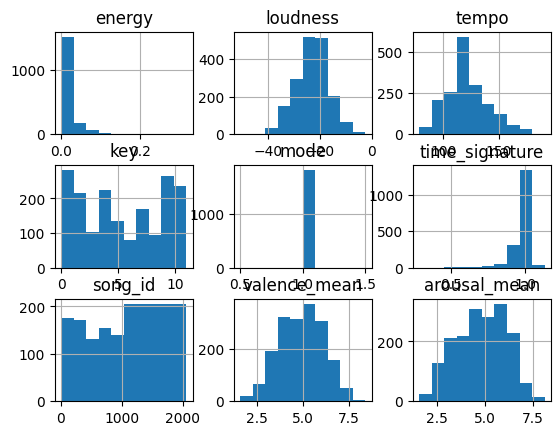

In [ ]:
music_df.hist()

In [ ]:
music_df['tempo'] = music_df['tempo'].apply(lambda x: x[0] if len(x) == 1 else x)
music_df['time_signature'] = music_df['time_signature'].apply(lambda x: x[0] if len(x) == 1 else x)

In [ ]:
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,valence_mean,arousal_mean
0,0.012146,-21.465645,139.674831,9,1,1.001031,2.0,3.10,3.00
1,0.017426,-25.533651,95.703125,4,1,0.988654,3.0,3.50,3.30
2,0.039658,-18.046253,112.347147,9,1,1.008252,4.0,5.70,5.50
3,0.024600,-20.400837,123.046875,11,1,1.018051,5.0,4.40,5.30
4,0.074468,-19.637709,120.185320,4,1,0.997166,7.0,5.80,6.40
...,...,...,...,...,...,...,...,...,...
1797,0.015683,-29.476341,178.205819,11,1,0.972539,2054.0,5.40,3.60
1798,0.030940,-15.287614,123.046875,9,1,1.004990,2055.0,5.00,5.20
1799,0.008828,-25.813923,99.384014,4,1,0.973944,2056.0,5.00,4.60
1800,0.033607,-13.712579,126.048018,11,1,0.990992,2057.0,3.17,6.83


## 다변량 회귀

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# 독립 변수 (features)
X = music_df[['energy', 'loudness', 'tempo', 'key', 'time_signature']]

# 종속 변수 (targets)
y = music_df[['valence_mean', 'arousal_mean']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 모델 생성
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 예측 수행
y_pred = model.predict(X_test)

# 평가 지표 계산
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 1.01076826268576
R^2 Score: 0.28089915088578193


## 신경망

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

In [52]:
# 독립 변수와 종속 변수 정의
X = music_df[['energy', 'loudness', 'tempo', 'key', 'time_signature']].values
y = music_df[['valence_mean', 'arousal_mean']].values

# 데이터 분할: 80% 학습용, 20% 검증용
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 텐서 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# 데이터로더
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

KeyError: "None of [Index(['energy', 'loudness', 'tempo', 'key', 'time_signature'], dtype='object')] are in the [columns]"

In [75]:
class MultivariateRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim=2):
        super(MultivariateRegressionModel, self).__init__()

        self.model = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.BatchNorm1d(32),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# loss function
def loss_fn(y_pred, y_true):
    # 각 출력에 대한 MSE 계산
    mse = nn.MSELoss(reduction='none')
    loss = mse(y_pred, y_true)
    # 각 출력의 손실 반환
    return loss.mean(dim=0)

In [81]:
input_dim = X_train_tensor.shape[1]
model = MultivariateRegressionModel(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 파라미터 설정
epochs = 30
train_loss_v = []
train_loss_a = []
val_loss_v = []
val_loss_a = []

# 훈련 루프
model.train()
for epoch in range(epochs):
    total_train_loss = torch.zeros(2)
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.sum().backward()
        optimizer.step()
        total_train_loss += loss.detach()
    avg_train_loss = total_train_loss / len(train_loader)

    # 검증 루프
    model.eval()
    with torch.no_grad():
        total_val_loss = torch.zeros(2)
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_val_loss += loss
        avg_val_loss = total_val_loss / len(val_loader)

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {avg_train_loss[0].item():.4f}, {avg_train_loss[1].item():.4f}, '
          f'Val Loss: {avg_val_loss[0].item():.4f}, {avg_val_loss[1].item():.4f}')

    train_loss_v.append(avg_train_loss[0].item())
    train_loss_a.append(avg_train_loss[1].item())
    val_loss_v.append(avg_val_loss[0].item())
    val_loss_a.append(avg_val_loss[1].item())

Epoch [1/30], Train Loss: 26.8667, 23.9383, Val Loss: 24.4925, 21.2800
Epoch [2/30], Train Loss: 19.7097, 16.5989, Val Loss: 11.9839, 9.0255
Epoch [3/30], Train Loss: 5.9474, 4.4407, Val Loss: 2.6328, 1.6393
Epoch [4/30], Train Loss: 1.4702, 1.3067, Val Loss: 1.1990, 1.0723
Epoch [5/30], Train Loss: 0.9444, 1.0839, Val Loss: 1.0880, 1.0036
Epoch [6/30], Train Loss: 0.8996, 1.0370, Val Loss: 1.0789, 0.9861
Epoch [7/30], Train Loss: 0.8722, 1.0163, Val Loss: 1.0486, 0.9745
Epoch [8/30], Train Loss: 0.8606, 1.0183, Val Loss: 1.0329, 0.9674
Epoch [9/30], Train Loss: 0.8512, 1.0005, Val Loss: 1.0128, 0.9532
Epoch [10/30], Train Loss: 0.8469, 1.0023, Val Loss: 1.0239, 0.9626
Epoch [11/30], Train Loss: 0.8427, 0.9945, Val Loss: 1.0182, 0.9497
Epoch [12/30], Train Loss: 0.8260, 0.9783, Val Loss: 1.0199, 0.9521
Epoch [13/30], Train Loss: 0.8382, 0.9849, Val Loss: 1.0310, 0.9730
Epoch [14/30], Train Loss: 0.8226, 0.9874, Val Loss: 1.0468, 0.9931
Epoch [15/30], Train Loss: 0.8241, 0.9863, Val Los

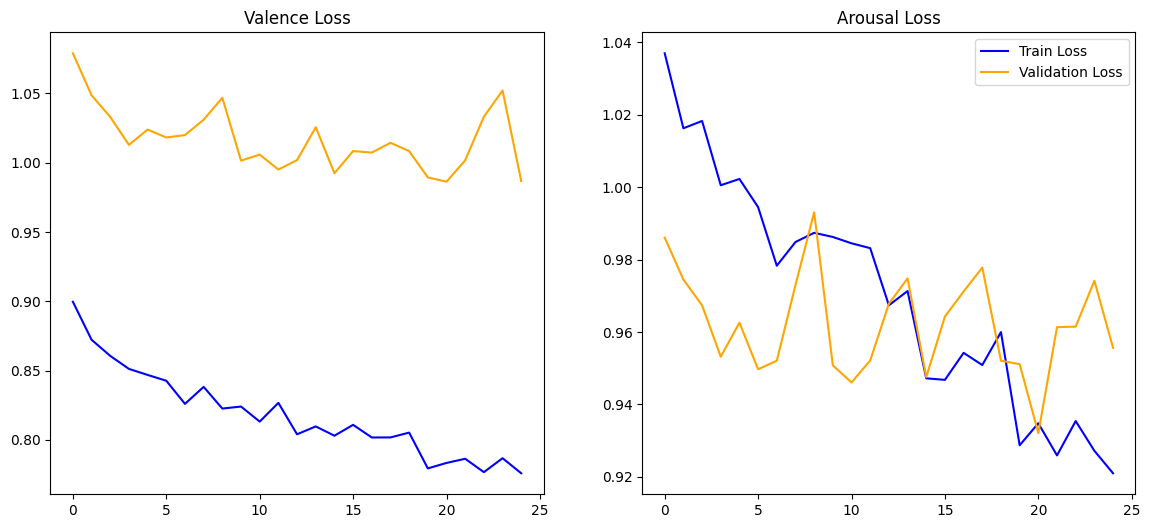

In [85]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].set_title('Valence Loss')
axs[0].plot(train_loss_v[5:], label='Train Loss', color='blue')
axs[0].plot(val_loss_v[5:], label='Validation Loss', color='orange')

axs[1].set_title('Arousal Loss')
axs[1].plot(train_loss_a[5:], label='Train Loss', color='blue')
axs[1].plot(val_loss_a[5:], label='Validation Loss', color='orange')
plt.legend()

In [86]:
# 테스트 데이터 예측
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_val_tensor)
    y_pred = y_pred_tensor.numpy()

# 평가 지표 계산
from sklearn.metrics import mean_squared_error, r2_score
y_test = y_val_tensor.numpy()
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred, multioutput='raw_values')

print(f'MSE for each output: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2 Score: {r2}')

MSE for each output: [0.9785938  0.95432955]
RMSE: [0.98923904 0.9768979 ]
R^2 Score: [0.26991218 0.35459483]


In [79]:
# 평균 계산
dummy_pred = torch.mean(y_train_tensor, dim=0).unsqueeze(0).expand(y_val_tensor.size(0), -1).cpu().numpy()

# 평가 지표 계산
dummy_mse = mean_squared_error(y_test, dummy_pred, multioutput='raw_values')
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(y_test, dummy_pred, multioutput='raw_values')

print(f'Dummy RMSE: {dummy_rmse}')
print(f'Dummy R^2 Score: {dummy_r2}')

Dummy RMSE: [1.1621872 1.2190019]
Dummy R^2 Score: [-0.00768507 -0.00494623]


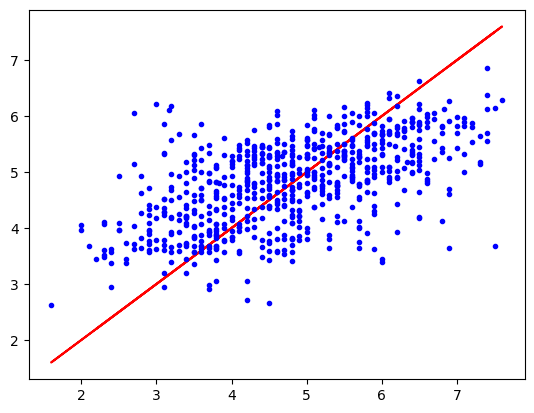

In [87]:
import matplotlib.pyplot as plt

plt.plot(y_test, y_test, 'r-')
plt.plot(y_test, y_pred, 'b.')